# ACTIVIDAD 2: REDES NEURONALES CONVOLUCIONALES

---

En esta actividad, vamos a trabajar con Convolutional Neural Networks para resolver un problema de clasificación de imágenes. En particular, vamos a clasificar imágenes de personajes de la conocida serie de los Simpsons.

Como las CNN profundas son un tipo de modelo bastante avanzado y computacionalmente costoso, se recomienda hacer la práctica en Google Colaboratory con soporte para GPUs. En [este enlace](https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) se explica cómo activar un entorno con GPUs. *Nota: para leer las imágenes y estandarizarlas al mismo tamaño se usa la librería opencv. Esta ĺibrería está ya instalada en el entorno de Colab, pero si trabajáis de manera local tendréis que instalarla.*

<center><img src="https://i.imgur.com/i8zIGqX.jpg" style="text-align: center" height="300px"></center>

El dataset a utilizar consiste en imágenes de personajes de los Simpsons extraídas directamente de capítulos de la serie. Este dataset ha sido recopilado por [Alexandre Attia](http://www.alexattia.fr/) y es más complejo que el dataset de Fashion MNIST que hemos utilizado hasta ahora. Aparte de tener más clases (vamos a utilizar los 18 personajes con más imágenes), los personajes pueden aparecer en distintas poses, en distintas posiciones de la imagen o con otros personajes en pantalla (si bien el personaje a clasificar siempre aparece en la posición predominante).

El dataset de training puede ser descargado desde aquí:

[Training data](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219337&authkey=AMzI92bJPx8Sd60) (~500MB)

Por otro lado, el dataset de test puede ser descargado de aquí:

[Test data](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219341&authkey=ANnjK3Uq1FhuAe8) (~10MB)

Antes de empezar la práctica, se recomienda descargar las imágenes y echarlas un vistazo.


## Carga de los datos

In [22]:
import cv2
import os
import numpy as np
import keras
from tensorflow import keras
import matplotlib.pyplot as plt
import glob
import tensorflow as tf
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [23]:
# Descargar el dataset desde Kaggle usando kagglehub
# Instalar kagglehub si no está instalado
!pip install -q kagglehub

import kagglehub

# Descargar el dataset de Simpsons desde Kaggle
# Dataset: https://www.kaggle.com/datasets/alexattia/the-simpsons-characters-dataset
print("Descargando dataset de Simpsons desde Kaggle usando kagglehub...")
print("Esto puede tardar varios minutos dependiendo de tu conexión...")

try:
    # Descargar la última versión del dataset
    path = kagglehub.dataset_download("alexattia/the-simpsons-characters-dataset")

    print(f"\n✅ Dataset descargado correctamente en: {path}")
    print(f"Contenido del directorio:")

    import os
    for item in os.listdir(path):
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            num_files = len([f for f in os.listdir(item_path) if os.path.isfile(os.path.join(item_path, f))])
            print(f"  📁 {item}/ ({num_files} archivos)")
        else:
            print(f"  📄 {item}")

except Exception as e:
    print(f"\n❌ Error al descargar el dataset: {e}")
    raise

Descargando dataset de Simpsons desde Kaggle usando kagglehub...
Esto puede tardar varios minutos dependiendo de tu conexión...
Using Colab cache for faster access to the 'the-simpsons-characters-dataset' dataset.

✅ Dataset descargado correctamente en: /kaggle/input/the-simpsons-characters-dataset
Contenido del directorio:
  📁 kaggle_simpson_testset/ (0 archivos)
  📄 weights.best.hdf5
  📁 simpsons_dataset/ (0 archivos)
  📄 annotation.txt
  📄 number_pic_char.csv
  📄 characters_illustration.png


In [24]:
# Esta variable contiene un mapeo de número de clase a personaje.
# Utilizamos sólo los 18 personajes del dataset que tienen más imágenes.
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson',
    3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy', 6: 'edna_krabappel',
    7: 'homer_simpson', 8: 'kent_brockman', 9: 'krusty_the_clown', 10: 'lisa_simpson',
    11: 'marge_simpson', 12: 'milhouse_van_houten', 13: 'moe_szyslak',
    14: 'ned_flanders', 15: 'nelson_muntz', 16: 'principal_skinner', 17: 'sideshow_bob'
}

# Vamos a standarizar todas las imágenes a tamaño 64x64
IMG_SIZE = 60

In [25]:
def load_train_set(dirname, map_characters, verbose=True):
    """Esta función carga los datos de training en imágenes.

    Como las imágenes tienen tamaños distintas, utilizamos la librería opencv
    para hacer un resize y adaptarlas todas a tamaño IMG_SIZE x IMG_SIZE.

    Args:
        dirname: directorio completo del que leer los datos
        map_characters: variable de mapeo entre labels y personajes
        verbose: si es True, muestra información de las imágenes cargadas

    Returns:
        X, y: X es un array con todas las imágenes cargadas con tamaño
                IMG_SIZE x IMG_SIZE
              y es un array con las labels de correspondientes a cada imagen
    """
    X_train = []
    y_train = []
    for label, character in map_characters.items():
        files = os.listdir(os.path.join(dirname, character))
        images = [file for file in files if file.endswith("jpg")]
        if verbose:
          print("Leyendo {} imágenes encontradas de {}".format(len(images), character))
        for image_name in images:
            image = cv2.imread(os.path.join(dirname, character, image_name))
            # Convertir de BGR a RGB
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            X_train.append(cv2.resize(image,(IMG_SIZE, IMG_SIZE)))
            y_train.append(label)
    return np.array(X_train), np.array(y_train)

In [26]:
def load_test_set(dirname, map_characters, verbose=True):
    """Esta función funciona de manera equivalente a la función load_train_set
    pero cargando los datos de test."""
    X_test = []
    y_test = []
    reverse_dict = {v: k for k, v in map_characters.items()}

    # Buscar imágenes con diferentes extensiones
    image_files = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
        image_files.extend(glob.glob(os.path.join(dirname, ext)))

    if verbose:
        print(f"Buscando imágenes en: {dirname}")
        print(f"Encontradas {len(image_files)} imágenes")

    for filename in image_files:
        # Obtener solo el nombre del archivo sin la ruta
        basename = os.path.basename(filename)
        # Extraer el nombre del personaje (todo menos el último segmento después del último _)
        char_name = "_".join(basename.split('_')[:-1])

        if char_name in reverse_dict:
            image = cv2.imread(filename)
            if image is not None:
                # Convertir de BGR a RGB
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
                X_test.append(image)
                y_test.append(reverse_dict[char_name])
        elif verbose and len(X_test) < 5:
            # Mostrar algunos nombres que no coinciden para debugging
            print(f"  ⚠️ No se encontró personaje para: {basename} (extraído: '{char_name}')")

    if verbose:
        print(f"Leídas {len(X_test)} imágenes de test válidas")
    return np.array(X_test), np.array(y_test)


In [27]:
# Configurar las rutas del dataset descargado con kagglehub
# La variable 'path' contiene la ubicación donde kagglehub descargó los datos

print("Configurando rutas del dataset...")

# Explorar la estructura del dataset descargado
import os

if 'path' in locals():
    print(f"✅ Path del dataset: {path}")

    # Listar el contenido para encontrar las carpetas de training y test
    contents = os.listdir(path)
    print(f"\nContenido del dataset:")
    for item in contents:
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            sub_contents = os.listdir(item_path)
            print(f"  📁 {item}/ ({len(sub_contents)} elementos)")
            # Mostrar algunos elementos
            for sub_item in sub_contents[:5]:
                sub_path = os.path.join(item_path, sub_item)
                if os.path.isdir(sub_path):
                    files = [f for f in os.listdir(sub_path) if f.endswith('.jpg') or f.endswith('.png')]
                    print(f"      📁 {sub_item}/ ({len(files)} imágenes)")
        else:
            print(f"  📄 {item}")

    # Buscar las carpetas de training y test
    # El dataset puede tener diferentes estructuras, buscar la correcta
    train_path = None
    test_path = None

    # Posibles nombres de carpetas
    for item in contents:
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            # Verificar si contiene carpetas de personajes
            sub_contents = os.listdir(item_path)
            if any(char in sub_contents for char in ['homer_simpson', 'bart_simpson', 'marge_simpson']):
                if 'train' in item.lower() or 'simpsons_dataset' in item.lower():
                    train_path = item_path
                elif 'test' in item.lower():
                    test_path = item_path

    # Si no se encontró con el patrón anterior, buscar directamente
    if train_path is None:
        # Quizás los personajes están directamente en 'path'
        direct_contents = os.listdir(path)
        if any(char in direct_contents for char in ['homer_simpson', 'bart_simpson', 'marge_simpson']):
            train_path = path

    DATASET_TRAIN_PATH = train_path if train_path else path

    # Buscar carpeta de test con varios nombres posibles
    if test_path is None:
        # Buscar en diferentes ubicaciones posibles
        possible_test_paths = [
            os.path.join(path, "kaggle_simpson_testset"),
            os.path.join(path, "kaggle_simpson_testset", "kaggle_simpson_testset"),
            os.path.join(path, "testset"),
            os.path.join(path, "test"),
        ]
        for possible_path in possible_test_paths:
            if os.path.exists(possible_path):
                # Verificar si contiene imágenes
                files = [f for f in os.listdir(possible_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
                if len(files) > 0:
                    test_path = possible_path
                    print(f"   ✅ Carpeta de test encontrada: {test_path} ({len(files)} archivos)")
                    break

    DATASET_TEST_PATH = test_path if test_path else None

    print(f"\n📂 Ruta de training: {DATASET_TRAIN_PATH}")
    print(f"📂 Ruta de test: {DATASET_TEST_PATH if DATASET_TEST_PATH else 'No encontrada'}")

    # Cargar los datos
    print("\nCargando datos del dataset...")
    X, y = load_train_set(DATASET_TRAIN_PATH, MAP_CHARACTERS)

    # Intentar cargar el test set
    if DATASET_TEST_PATH and os.path.exists(DATASET_TEST_PATH):
        X_t, y_t = load_test_set(DATASET_TEST_PATH, MAP_CHARACTERS)
        if len(X_t) == 0:
            print(f"\n⚠️ No se pudieron cargar imágenes de test desde: {DATASET_TEST_PATH}")
            print("   Creando conjunto de test desde training...")
            test_size = int(len(X) * 0.1)
            X_t, y_t = X[-test_size:], y[-test_size:]
            X, y = X[:-test_size], y[:-test_size]
            print(f"   Conjunto de test temporal creado: {len(X_t)} imágenes")
    else:
        print(f"\n⚠️ No se encontró directorio de test")
        print("   Usando los últimos datos de training como conjunto de test temporal...")
        # Usar una porción del training como test
        test_size = int(len(X) * 0.1)
        X_t, y_t = X[-test_size:], y[-test_size:]
        X, y = X[:-test_size], y[:-test_size]
        print(f"   Conjunto de test temporal creado: {len(X_t)} imágenes")

else:
    print("❌ Error: La variable 'path' no está definida.")
    print("   Ejecuta primero la celda de descarga del dataset.")

Configurando rutas del dataset...
✅ Path del dataset: /kaggle/input/the-simpsons-characters-dataset

Contenido del dataset:
  📁 kaggle_simpson_testset/ (1 elementos)
      📁 kaggle_simpson_testset/ (990 imágenes)
  📄 weights.best.hdf5
  📁 simpsons_dataset/ (43 elementos)
      📁 rainier_wolfcastle/ (45 imágenes)
      📁 maggie_simpson/ (128 imágenes)
      📁 krusty_the_clown/ (1206 imágenes)
      📁 waylon_smithers/ (181 imágenes)
      📁 professor_john_frink/ (65 imágenes)
  📄 annotation.txt
  📄 number_pic_char.csv
  📄 characters_illustration.png
   ✅ Carpeta de test encontrada: /kaggle/input/the-simpsons-characters-dataset/kaggle_simpson_testset/kaggle_simpson_testset (990 archivos)

📂 Ruta de training: /kaggle/input/the-simpsons-characters-dataset/simpsons_dataset
📂 Ruta de test: /kaggle/input/the-simpsons-characters-dataset/kaggle_simpson_testset/kaggle_simpson_testset

Cargando datos del dataset...
Leyendo 913 imágenes encontradas de abraham_grampa_simpson
Leyendo 623 imágenes enc

In [28]:
# Vamos a barajar aleatoriamente los datos. Esto es importante ya que si no
# lo hacemos y, por ejemplo, cogemos el 20% de los datos finales como validation
# set, estaremos utilizando solo un pequeño número de personajes, ya que
# las imágenes se leen secuencialmente personaje a personaje.
perm = np.random.permutation(len(X))
X, y = X[perm], y[perm]

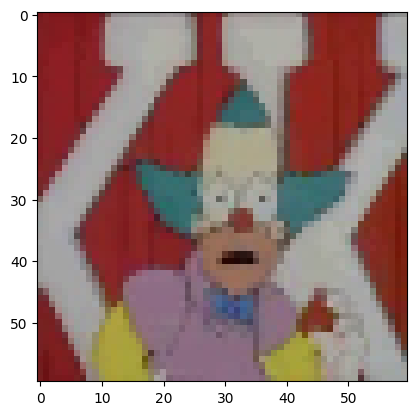

In [29]:
plt.imshow(X_t[2]) # recordad que siempre es preferible trabajar en blanco y negro


## Ejercicio

Utilizando Convolutional Neural Networks con Keras, entrenar un clasificador que sea capaz de reconocer personajes en imágenes de los Simpsons con una accuracy en el dataset de test de, al menos, **85%**. Redactar un informe analizando varias de las alternativas probadas y los resultados obtenidos.

A continuación se detallan una serie de aspectos orientativos que podrían ser analizados en vuestro informe (no es necesario tratar todos ellos ni mucho menos, esto son ideas orientativas de aspectos que podéis explorar):

*   Análisis de los datos a utilizar.
*   Análisis de resultados, obtención de métricas de *precision* y *recall* por clase y análisis de qué clases obtienen mejores o peores resultados.
*   Análisis visual de los errores de la red. ¿Qué tipo de imágenes o qué personajes dan más problemas a nuestro modelo?
*   Comparación de modelos CNNs con un modelo de Fully Connected para este problema.
*   Utilización de distintas arquitecturas CNNs, comentando aspectos como su profundidad, hiperparámetros utilizados, optimizador, uso de técnicas de regularización, *batch normalization*, etc.
*   [ *algo más difícil* ] Utilización de *data augmentation*. Esto puede conseguirse con la clase [ImageDataGenerator](https://keras.io/preprocessing/image/#imagedatagenerator-class) de Keras.

Notas:
* Recuerda partir los datos en training/validation para tener una buena estimación de los valores que nuestro modelo tendrá en los datos de test, así como comprobar que no estamos cayendo en overfitting. Una posible partición puede ser 80 / 20.
* No es necesario mostrar en el notebook las trazas de entrenamiento de todos los modelos entrenados, si bien una buena idea seria guardar gráficas de esos entrenamientos para el análisis. Sin embargo, **se debe mostrar el entrenamiento completo del mejor modelo obtenido y la evaluación de los datos de test con este modelo**.
* Las imágenes **no están normalizadas**. Hay que normalizarlas como hemos hecho en trabajos anteriores.
* El test set del problema tiene imágenes un poco más "fáciles", por lo que es posible encontrarse con métricas en el test set bastante mejores que en el training set.

In [30]:
# Importar librerías adicionales necesarias
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_fscore_support
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("Librerías importadas correctamente")

Librerías importadas correctamente


ANÁLISIS EXPLORATORIO DEL DATASET DE SIMPSONS

Total de imágenes de entrenamiento: 18992
Total de imágenes de test: 890
Tamaño de cada imagen: 60x60 píxeles
Número de canales: 3 (RGB)
Número de clases: 18
Rango de valores de píxeles: [0, 255]

--- Distribución de clases en Training Set ---
                   Clase  Cantidad  Porcentaje
  abraham_grampa_simpson       913        4.81
  apu_nahasapeemapetilon       623        3.28
            bart_simpson      1342        7.07
charles_montgomery_burns      1193        6.28
            chief_wiggum       986        5.19
          comic_book_guy       469        2.47
          edna_krabappel       457        2.41
           homer_simpson      2246       11.83
           kent_brockman       498        2.62
        krusty_the_clown      1206        6.35
            lisa_simpson      1354        7.13
           marge_simpson      1291        6.80
     milhouse_van_houten      1079        5.68
             moe_szyslak      1452        7.65
    

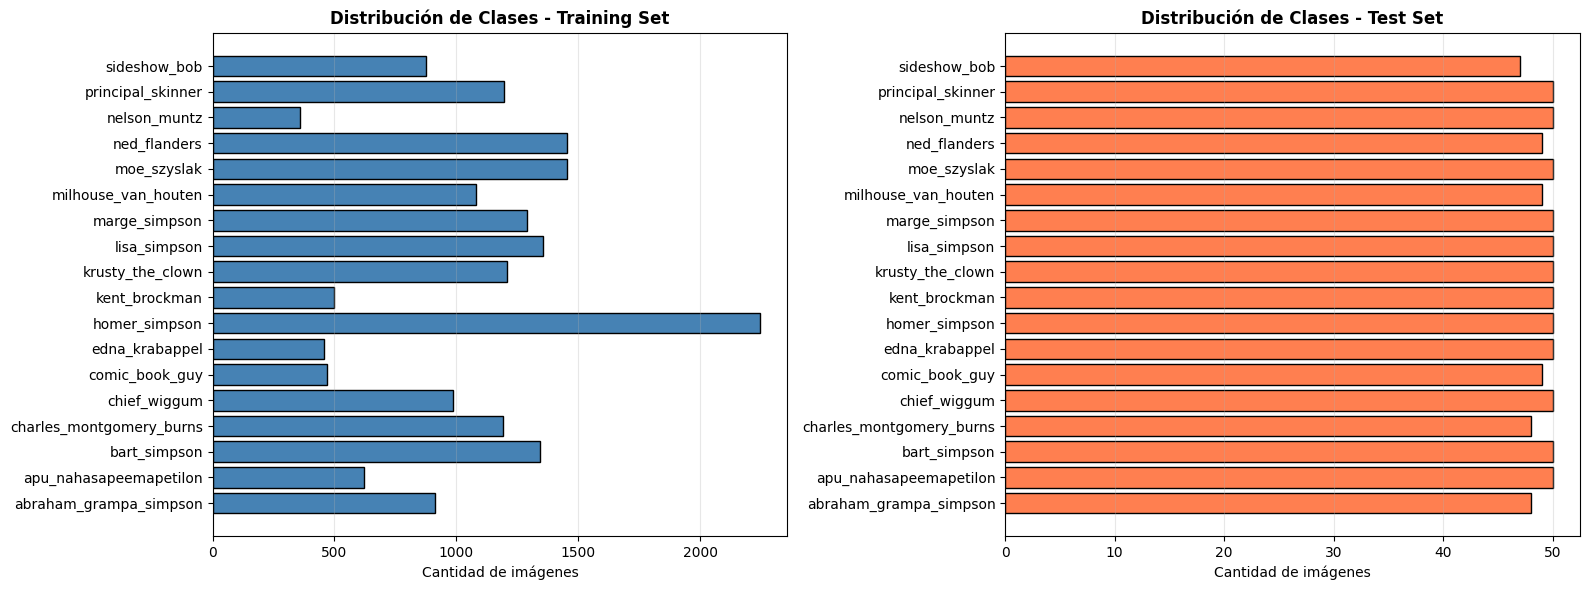


--- Muestras de cada personaje ---


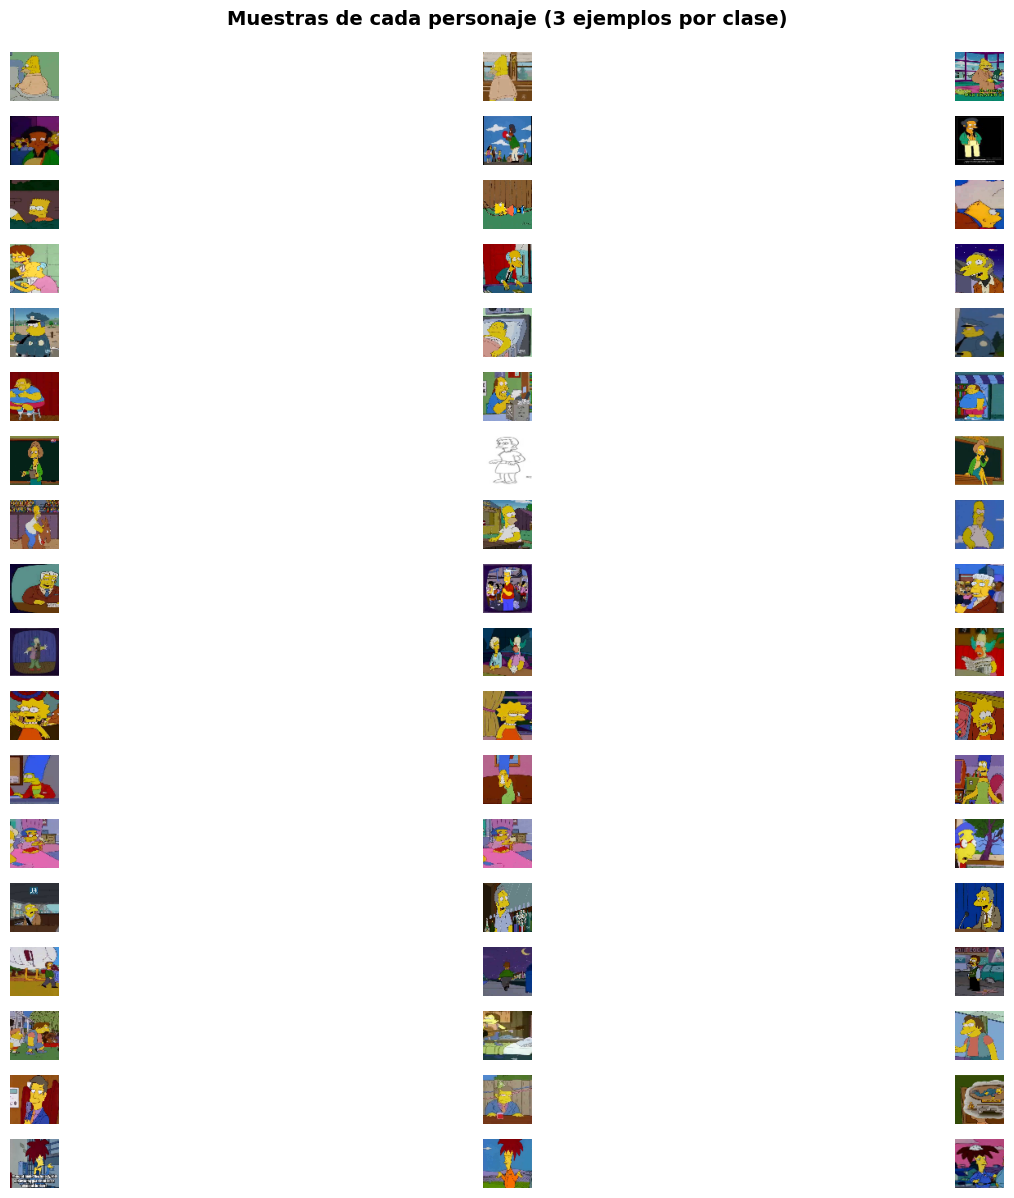

In [31]:
# ANÁLISIS EXPLORATORIO DE DATOS
print("="*80)
print("ANÁLISIS EXPLORATORIO DEL DATASET DE SIMPSONS")
print("="*80 + "\n")

# Información básica
print(f"Total de imágenes de entrenamiento: {len(X)}")
print(f"Total de imágenes de test: {len(X_t)}")
print(f"Tamaño de cada imagen: {IMG_SIZE}x{IMG_SIZE} píxeles")
print(f"Número de canales: {X.shape[-1]} (RGB)")
print(f"Número de clases: {len(MAP_CHARACTERS)}")
print(f"Rango de valores de píxeles: [{X.min()}, {X.max()}]")

# Distribución de clases en training
print("\n--- Distribución de clases en Training Set ---")
unique_train, counts_train = np.unique(y, return_counts=True)
df_dist_train = pd.DataFrame({
    'Clase': [MAP_CHARACTERS[i] for i in unique_train],
    'Cantidad': counts_train,
    'Porcentaje': (counts_train / len(y) * 100).round(2)
})
print(df_dist_train.to_string(index=False))

# Distribución de clases en test
print("\n--- Distribución de clases en Test Set ---")
unique_test, counts_test = np.unique(y_t, return_counts=True)
df_dist_test = pd.DataFrame({
    'Clase': [MAP_CHARACTERS[i] for i in unique_test],
    'Cantidad': counts_test,
    'Porcentaje': (counts_test / len(y_t) * 100).round(2)
})
print(df_dist_test.to_string(index=False))

# Visualización de la distribución
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Training set
ax1.barh([MAP_CHARACTERS[i] for i in unique_train], counts_train, color='steelblue', edgecolor='black')
ax1.set_xlabel('Cantidad de imágenes')
ax1.set_title('Distribución de Clases - Training Set', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Test set
ax2.barh([MAP_CHARACTERS[i] for i in unique_test], counts_test, color='coral', edgecolor='black')
ax2.set_xlabel('Cantidad de imágenes')
ax2.set_title('Distribución de Clases - Test Set', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Visualizar muestras de cada personaje
print("\n--- Muestras de cada personaje ---")
plt.figure(figsize=(18, 12))
for idx, (label, character) in enumerate(MAP_CHARACTERS.items()):
    # Encontrar las primeras imágenes de cada personaje
    indices = np.where(y == label)[0]
    for i in range(min(3, len(indices))):
        plt.subplot(18, 3, idx*3 + i + 1)
        plt.imshow(X[indices[i]])
        if i == 0:
            plt.ylabel(character.replace('_', ' ').title(), fontsize=8, rotation=0, ha='right', va='center')
        plt.axis('off')

plt.suptitle('Muestras de cada personaje (3 ejemplos por clase)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "="*80)

In [32]:
# PREPARACIÓN DE DATOS
print("="*80)
print("PREPARACIÓN DE DATOS")
print("="*80 + "\n")

# Normalizar las imágenes (0-255 -> 0-1)
print("Normalizando imágenes...")
X_normalized = X.astype('float32') / 255.0
X_test_normalized = X_t.astype('float32') / 255.0

print(f"Rango normalizado - Training: [{X_normalized.min():.2f}, {X_normalized.max():.2f}]")
print(f"Rango normalizado - Test: [{X_test_normalized.min():.2f}, {X_test_normalized.max():.2f}]")

# Convertir etiquetas a one-hot encoding
print("\nConvirtiendo etiquetas a one-hot encoding...")
y_categorical = keras.utils.to_categorical(y, len(MAP_CHARACTERS))
y_test_categorical = keras.utils.to_categorical(y_t, len(MAP_CHARACTERS))

print(f"Forma de y_categorical: {y_categorical.shape}")
print(f"Forma de y_test_categorical: {y_test_categorical.shape}")

# Dividir datos en training y validation (80/20)
print("\nDividiendo datos en Training y Validation (80/20)...")
split_idx = int(len(X_normalized) * 0.8)

X_train = X_normalized[:split_idx]
X_val = X_normalized[split_idx:]
y_train = y_categorical[:split_idx]
y_val = y_categorical[split_idx:]

print(f"\nConjunto de Training: {X_train.shape[0]} imágenes")
print(f"Conjunto de Validation: {X_val.shape[0]} imágenes")
print(f"Conjunto de Test: {X_test_normalized.shape[0]} imágenes")

print("\n" + "="*80)

PREPARACIÓN DE DATOS

Normalizando imágenes...
Rango normalizado - Training: [0.00, 1.00]
Rango normalizado - Test: [0.00, 1.00]

Convirtiendo etiquetas a one-hot encoding...
Forma de y_categorical: (18992, 18)
Forma de y_test_categorical: (890, 18)

Dividiendo datos en Training y Validation (80/20)...

Conjunto de Training: 15193 imágenes
Conjunto de Validation: 3799 imágenes
Conjunto de Test: 890 imágenes



In [33]:
# CONSTRUCCIÓN DEL MODELO CNN
print("="*80)
print("CONSTRUCCIÓN DEL MODELO CNN PARA SIMPSONS")
print("="*80 + "\n")

print("Arquitectura: CNN con 3 bloques convolucionales + Batch Normalization + Dropout")
print(f"Input shape: {IMG_SIZE}x{IMG_SIZE}x3 (RGB)")
print(f"Output: {len(MAP_CHARACTERS)} clases (personajes)")
print("="*80 + "\n")

# Construir modelo CNN
model = keras.models.Sequential([
    # Primer bloque convolucional
    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                        input_shape=(IMG_SIZE, IMG_SIZE, 3), name='conv1'),
    keras.layers.BatchNormalization(name='bn1'),
    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1_2'),
    keras.layers.BatchNormalization(name='bn1_2'),
    keras.layers.MaxPooling2D((2, 2), name='pool1'),
    keras.layers.Dropout(0.25, name='dropout1'),

    # Segundo bloque convolucional
    keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
    keras.layers.BatchNormalization(name='bn2'),
    keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2_2'),
    keras.layers.BatchNormalization(name='bn2_2'),
    keras.layers.MaxPooling2D((2, 2), name='pool2'),
    keras.layers.Dropout(0.25, name='dropout2'),

    # Tercer bloque convolucional
    keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3'),
    keras.layers.BatchNormalization(name='bn3'),
    keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3_2'),
    keras.layers.BatchNormalization(name='bn3_2'),
    keras.layers.MaxPooling2D((2, 2), name='pool3'),
    keras.layers.Dropout(0.25, name='dropout3'),

    # Capas densas
    keras.layers.Flatten(name='flatten'),
    keras.layers.Dense(256, activation='relu', name='dense1'),
    keras.layers.BatchNormalization(name='bn_dense1'),
    keras.layers.Dropout(0.5, name='dropout4'),
    keras.layers.Dense(128, activation='relu', name='dense2'),
    keras.layers.BatchNormalization(name='bn_dense2'),
    keras.layers.Dropout(0.5, name='dropout5'),
    keras.layers.Dense(len(MAP_CHARACTERS), activation='softmax', name='output')
])

# Compilar el modelo
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Mostrar resumen del modelo
print("\n--- Resumen del Modelo ---")
model.summary()

print("\n" + "="*80)

CONSTRUCCIÓN DEL MODELO CNN PARA SIMPSONS

Arquitectura: CNN con 3 bloques convolucionales + Batch Normalization + Dropout
Input shape: 60x60x3 (RGB)
Output: 18 clases (personajes)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Resumen del Modelo ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 60, 60, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 60, 60, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 60, 60, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 60, 60, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 30, 30, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 30, 30, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 30, 30, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 30, 30, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 15, 15, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 15, 15, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_2 (BatchNormalization)      │ (None, 15, 15, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense1 (BatchNormalization)  │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout4 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense2 (BatchNormalization)  │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout5 (Dropout)              │ (None, 128)            │             

 Total params: 1,931,442 (7.37 MB)

 Trainable params: 1,929,778 (7.36 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [34]:
# ENTRENAMIENTO DEL MODELO
print("="*80)
print("ENTRENAMIENTO DEL MODELO CNN")
print("="*80 + "\n")

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

print("Callbacks configurados:")
print("  - EarlyStopping: patience=20, monitor='val_loss'")
print("  - ReduceLROnPlateau: factor=0.5, patience=5")
print("\nIniciando entrenamiento...\n")

# Entrenar el modelo
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\n" + "="*80)
print("ENTRENAMIENTO COMPLETADO")
print("="*80)

ENTRENAMIENTO DEL MODELO CNN

Callbacks configurados:
  - EarlyStopping: patience=20, monitor='val_loss'
  - ReduceLROnPlateau: factor=0.5, patience=5

Iniciando entrenamiento...

Epoch 1/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 37s 69ms/step - accuracy: 0.1731 - loss: 3.2580 - val_accuracy: 0.1482 - val_loss: 2.9893 - learning_rate: 0.0010
Epoch 2/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4548 - loss: 1.8646 - val_accuracy: 0.3685 - val_loss: 2.0142 - learning_rate: 0.0010
Epoch 3/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.5755 - loss: 1.3944 - val_accuracy: 0.6386 - val_loss: 1.1629 - learning_rate: 0.0010
Epoch 4/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6602 - loss: 1.1254 - val_accuracy: 0.7136 - val_loss: 0.9374 - learning_rate: 0.0010
Epoch 5/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7342 - loss: 0.8708 - val_accuracy: 0.6612 - val_loss: 1.1762 - learning_rate: 0.0010
Epoch 6/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/

ANÁLISIS DE CURVAS DE APRENDIZAJE



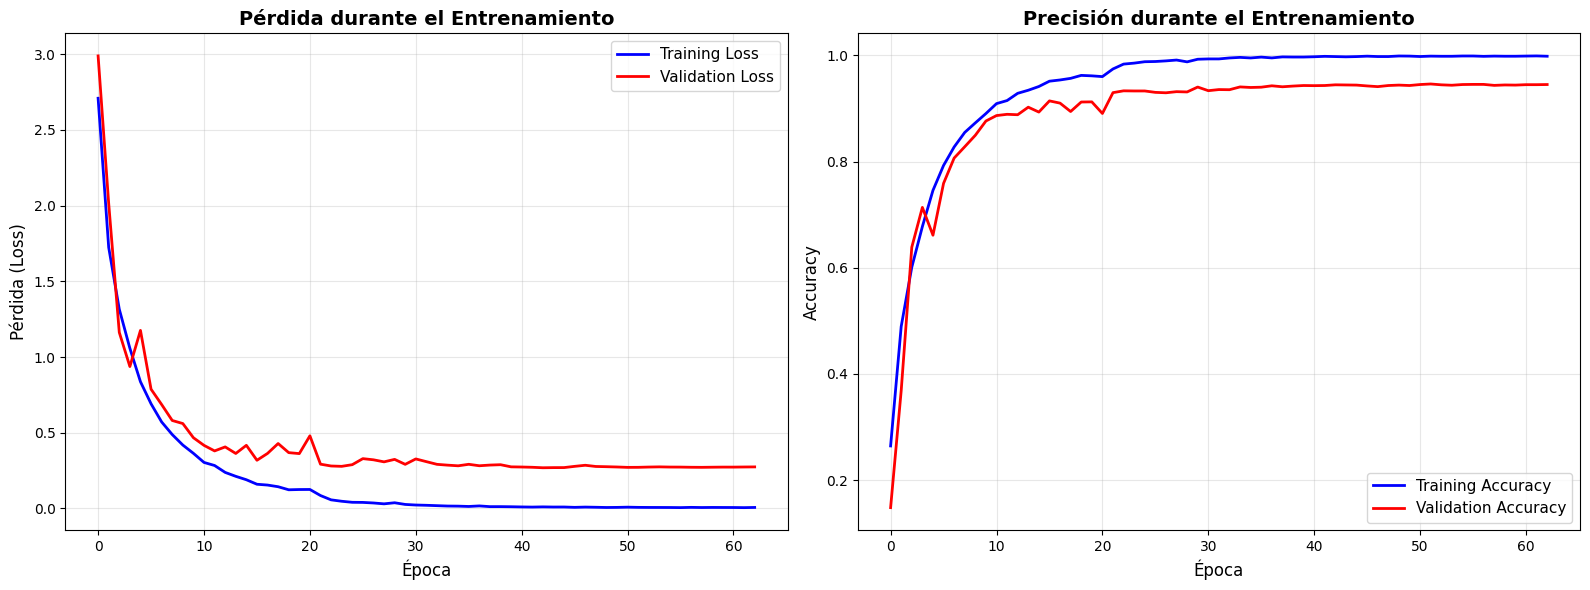


Épocas entrenadas: 63
Mejor época: 43
Mejor val_loss: 0.2688
Mejor val_accuracy: 0.9445

Accuracy final Training: 0.9983
Accuracy final Validation: 0.9450
Diferencia: 0.0533
⚠️ Ligero overfitting (diferencia > 5%)



In [35]:
# VISUALIZACIÓN DE CURVAS DE APRENDIZAJE
print("="*80)
print("ANÁLISIS DE CURVAS DE APRENDIZAJE")
print("="*80 + "\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de pérdida
ax1.plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
ax1.set_title('Pérdida durante el Entrenamiento', fontsize=14, fontweight='bold')
ax1.set_xlabel('Época', fontsize=12)
ax1.set_ylabel('Pérdida (Loss)', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Gráfico de accuracy
ax2.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='blue')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='red')
ax2.set_title('Precisión durante el Entrenamiento', fontsize=14, fontweight='bold')
ax2.set_xlabel('Época', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Información de las curvas
epochs_trained = len(history.history['loss'])
best_epoch = np.argmin(history.history['val_loss'])
best_val_loss = history.history['val_loss'][best_epoch]
best_val_acc = history.history['val_accuracy'][best_epoch]

print(f"\nÉpocas entrenadas: {epochs_trained}")
print(f"Mejor época: {best_epoch + 1}")
print(f"Mejor val_loss: {best_val_loss:.4f}")
print(f"Mejor val_accuracy: {best_val_acc:.4f}")

# Análisis de overfitting
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
diff_acc = final_train_acc - final_val_acc

print(f"\nAccuracy final Training: {final_train_acc:.4f}")
print(f"Accuracy final Validation: {final_val_acc:.4f}")
print(f"Diferencia: {diff_acc:.4f}")

if diff_acc > 0.1:
    print("⚠️ ADVERTENCIA: Posible overfitting detectado (diferencia > 10%)")
elif diff_acc > 0.05:
    print("⚠️ Ligero overfitting (diferencia > 5%)")
else:
    print("✅ Modelo bien generalizado")

print("\n" + "="*80)

In [36]:
# EVALUACIÓN EN CONJUNTO DE TEST
print("="*80)
print("EVALUACIÓN EN CONJUNTO DE TEST")
print("="*80 + "\n")

# Evaluar el modelo en el conjunto de test
test_loss, test_accuracy = model.evaluate(X_test_normalized, y_test_categorical, verbose=0)

print(f"Pérdida en Test: {test_loss:.4f}")
print(f"Accuracy en Test: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Verificar si cumple el objetivo
if test_accuracy >= 0.85:
    print(f"\n✅ ¡OBJETIVO CUMPLIDO! Accuracy >= 85%")
    print(f"   Superación del objetivo: +{(test_accuracy - 0.85)*100:.2f}%")
else:
    print(f"\n❌ Objetivo no alcanzado. Faltan {(0.85 - test_accuracy)*100:.2f}% para llegar al 85%")

# Realizar predicciones
print("\nRealizando predicciones en el conjunto de test...")
y_pred_proba = model.predict(X_test_normalized, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print(f"Predicciones realizadas: {len(y_pred)}")
print("\n" + "="*80)

EVALUACIÓN EN CONJUNTO DE TEST

Pérdida en Test: 0.0513
Accuracy en Test: 0.9865 (98.65%)

✅ ¡OBJETIVO CUMPLIDO! Accuracy >= 85%
   Superación del objetivo: +13.65%

Realizando predicciones en el conjunto de test...
Predicciones realizadas: 890



In [37]:
# MÉTRICAS DETALLADAS
print("="*80)
print("MÉTRICAS DETALLADAS DE CLASIFICACIÓN")
print("="*80 + "\n")

# Calcular métricas globales
accuracy = accuracy_score(y_t, y_pred)
precision_macro = precision_score(y_t, y_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_t, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_t, y_pred, average='macro', zero_division=0)

print("--- Métricas Globales ---")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision (macro): {precision_macro:.4f}")
print(f"Recall (macro): {recall_macro:.4f}")
print(f"F1-Score (macro): {f1_macro:.4f}")

# Reporte de clasificación completo
print("\n--- Reporte de Clasificación por Clase ---")
character_names = [MAP_CHARACTERS[i].replace('_', ' ').title() for i in range(len(MAP_CHARACTERS))]
print(classification_report(y_t, y_pred, target_names=character_names, zero_division=0))

# Métricas por clase
print("\n--- Análisis Detallado por Personaje ---")
precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
    y_t, y_pred, average=None, zero_division=0
)

df_metricas = pd.DataFrame({
    'Personaje': character_names,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Muestras': support
})

df_metricas = df_metricas.sort_values('F1-Score', ascending=False)
print(df_metricas.to_string(index=False))

# Top 5 y Bottom 5
print("\n🏆 TOP 5 - Mejor F1-Score:")
for idx, row in df_metricas.head(5).iterrows():
    print(f"  {row['Personaje']}: {row['F1-Score']:.4f} (Precision: {row['Precision']:.4f}, Recall: {row['Recall']:.4f})")

print("\n⚠️ BOTTOM 5 - Peor F1-Score:")
for idx, row in df_metricas.tail(5).iterrows():
    print(f"  {row['Personaje']}: {row['F1-Score']:.4f} (Precision: {row['Precision']:.4f}, Recall: {row['Recall']:.4f})")

print("\n" + "="*80)

MÉTRICAS DETALLADAS DE CLASIFICACIÓN

--- Métricas Globales ---
Accuracy: 0.9865 (98.65%)
Precision (macro): 0.9870
Recall (macro): 0.9865
F1-Score (macro): 0.9865

--- Reporte de Clasificación por Clase ---
                          precision    recall  f1-score   support

  Abraham Grampa Simpson       0.98      0.96      0.97        48
  Apu Nahasapeemapetilon       0.96      1.00      0.98        50
            Bart Simpson       0.96      0.98      0.97        50
Charles Montgomery Burns       1.00      0.98      0.99        48
            Chief Wiggum       1.00      1.00      1.00        50
          Comic Book Guy       1.00      0.98      0.99        49
          Edna Krabappel       1.00      0.98      0.99        50
           Homer Simpson       0.94      1.00      0.97        50
           Kent Brockman       1.00      0.94      0.97        50
        Krusty The Clown       0.98      1.00      0.99        50
            Lisa Simpson       0.98      0.98      0.98        50

MATRIZ DE CONFUSIÓN



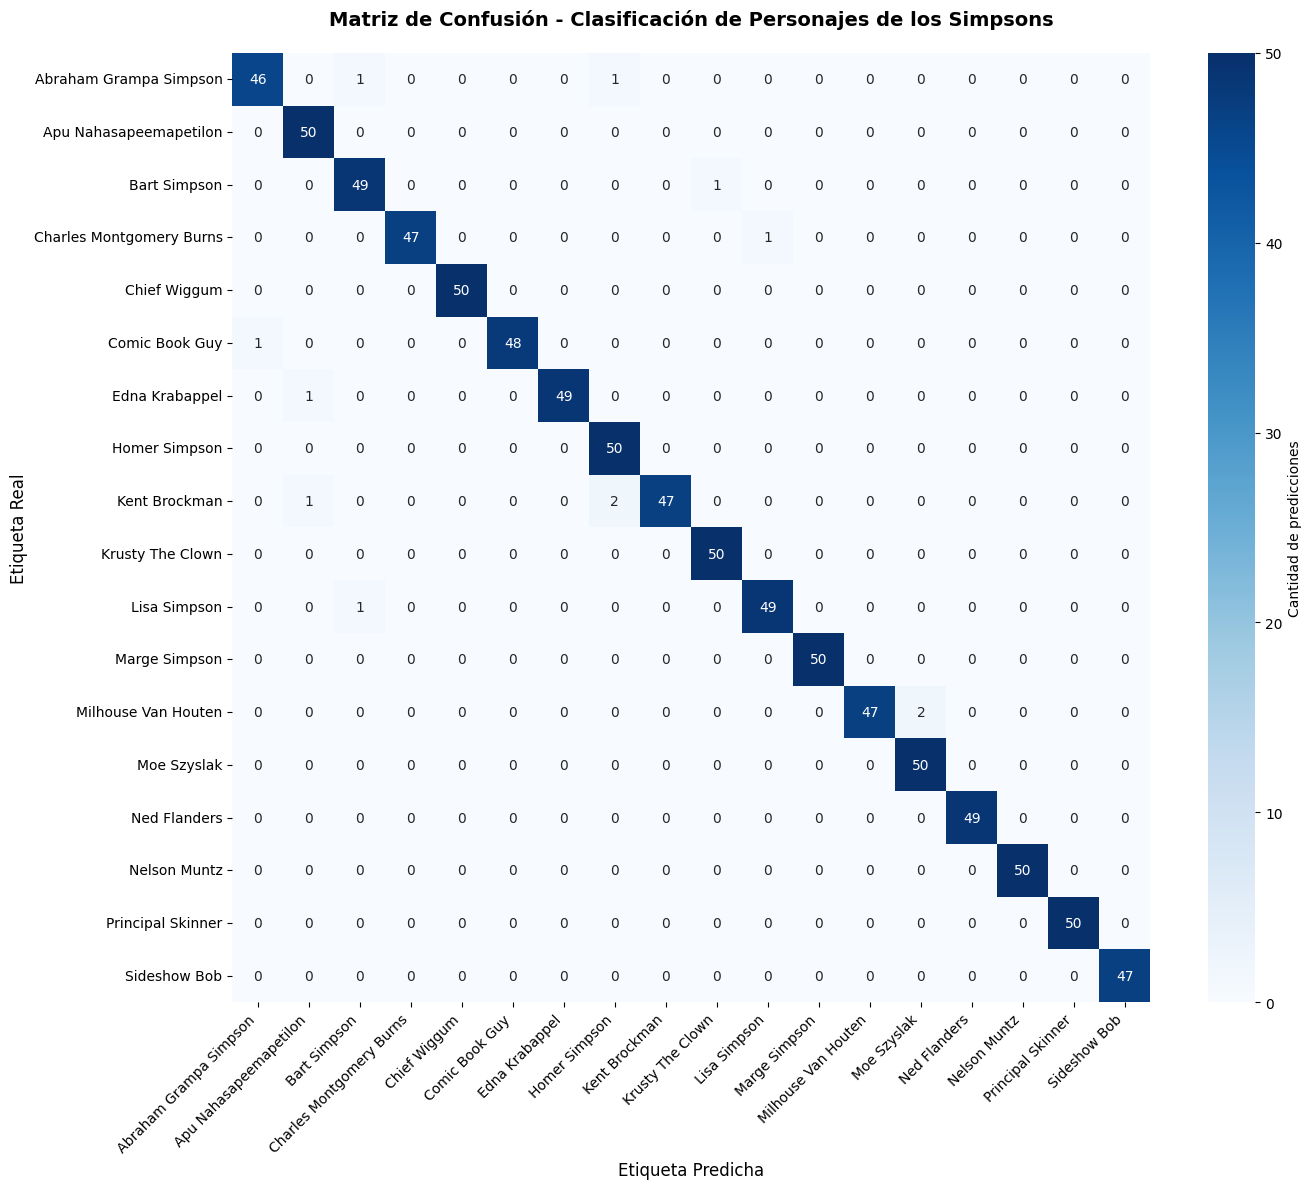


--- Análisis de Confusiones Más Comunes ---

Top 10 confusiones más frecuentes:
                    Real               Predicho  Cantidad
           Kent Brockman          Homer Simpson         2
     Milhouse Van Houten            Moe Szyslak         2
  Abraham Grampa Simpson          Homer Simpson         1
  Abraham Grampa Simpson           Bart Simpson         1
            Bart Simpson       Krusty The Clown         1
Charles Montgomery Burns           Lisa Simpson         1
          Edna Krabappel Apu Nahasapeemapetilon         1
          Comic Book Guy Abraham Grampa Simpson         1
           Kent Brockman Apu Nahasapeemapetilon         1
            Lisa Simpson           Bart Simpson         1



In [38]:
# MATRIZ DE CONFUSIÓN
print("="*80)
print("MATRIZ DE CONFUSIÓN")
print("="*80 + "\n")

# Calcular matriz de confusión
cm = confusion_matrix(y_t, y_pred)

# Visualización de la matriz de confusión
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=character_names,
            yticklabels=character_names,
            cbar_kws={'label': 'Cantidad de predicciones'})
plt.title('Matriz de Confusión - Clasificación de Personajes de los Simpsons',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Etiqueta Real', fontsize=12)
plt.xlabel('Etiqueta Predicha', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Analizar confusiones más comunes
print("\n--- Análisis de Confusiones Más Comunes ---")
# Obtener las confusiones (excluyendo la diagonal)
confusions = []
for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm[i][j] > 0:
            confusions.append({
                'Real': MAP_CHARACTERS[i].replace('_', ' ').title(),
                'Predicho': MAP_CHARACTERS[j].replace('_', ' ').title(),
                'Cantidad': cm[i][j]
            })

# Ordenar por cantidad
confusions_df = pd.DataFrame(confusions).sort_values('Cantidad', ascending=False)

if len(confusions_df) > 0:
    print("\nTop 10 confusiones más frecuentes:")
    print(confusions_df.head(10).to_string(index=False))
else:
    print("\n✅ ¡No hay confusiones! Clasificación perfecta.")

print("\n" + "="*80)

VISUALIZACIÓN DE MÉTRICAS POR CLASE



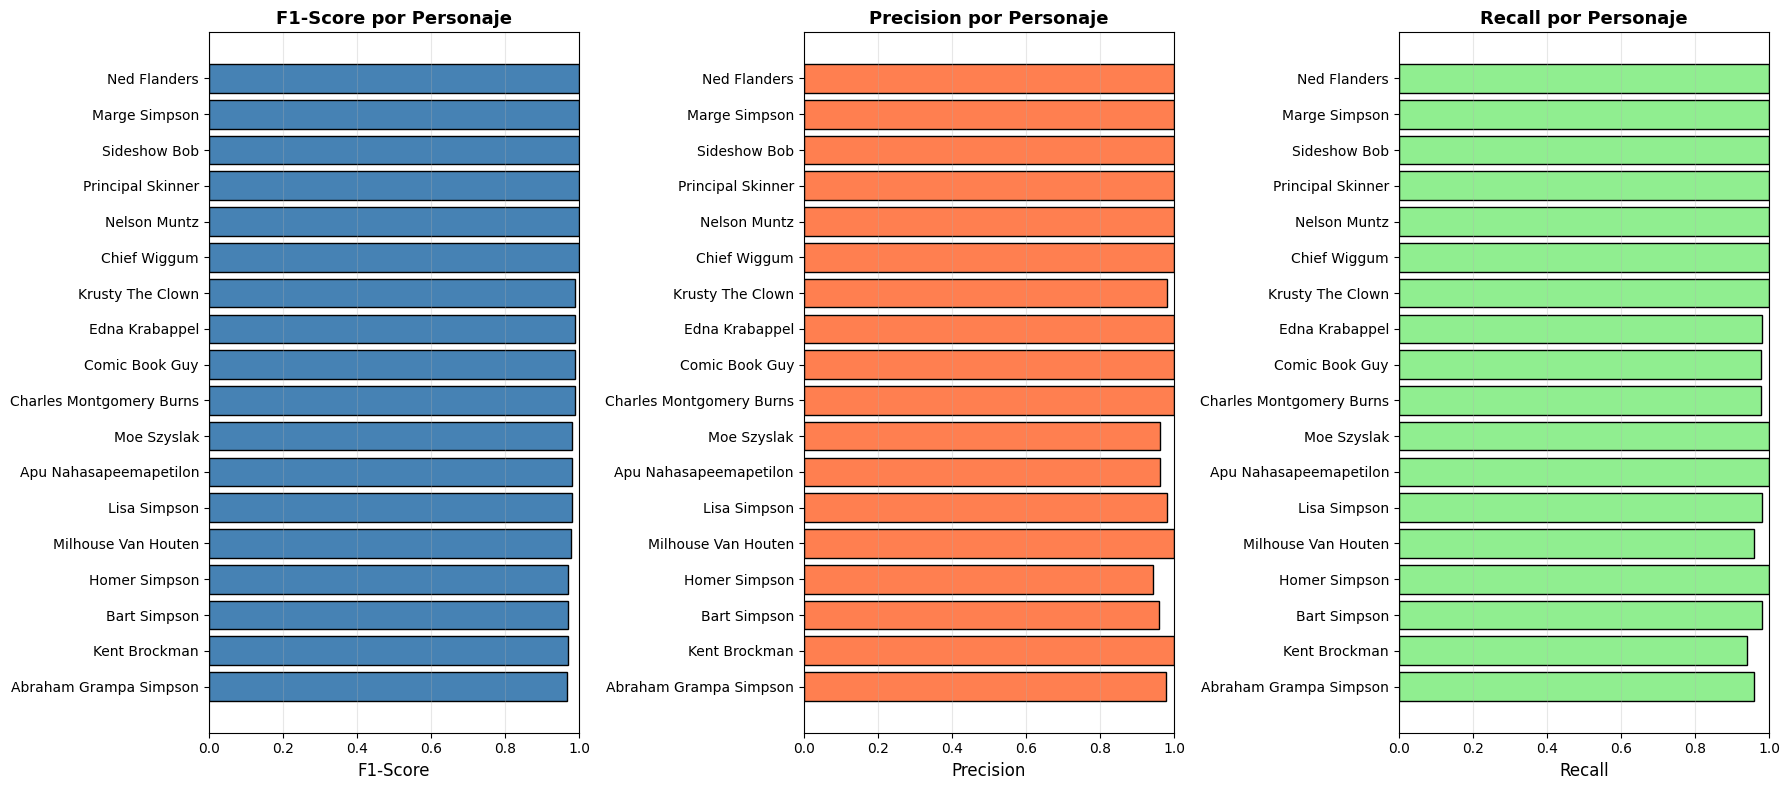


--- Comparación de Métricas Promedio ---


<Figure size 800x800 with 0 Axes>

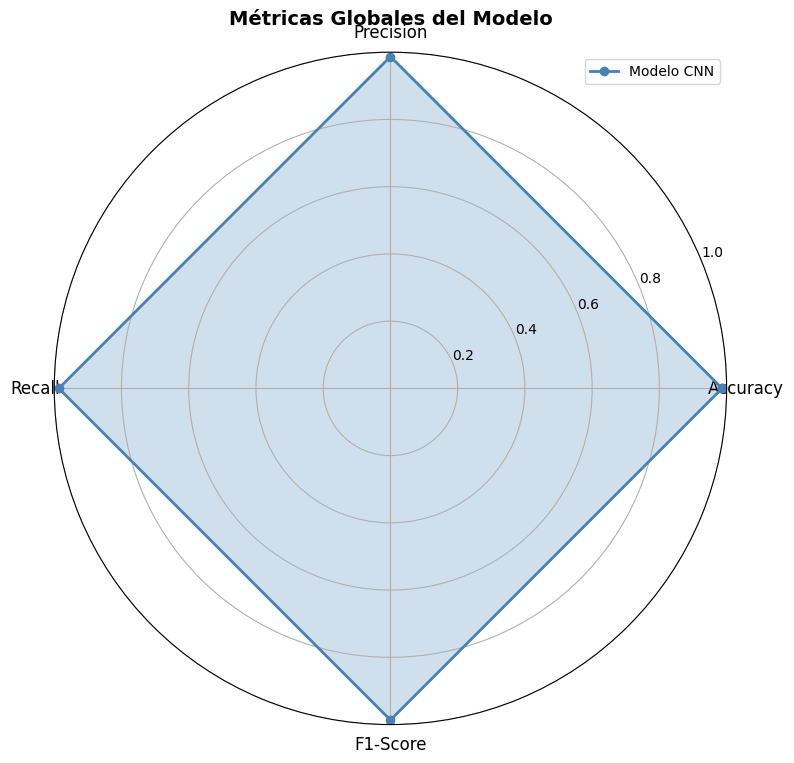

In [39]:
# VISUALIZACIÓN DE MÉTRICAS POR CLASE
print("="*80)
print("VISUALIZACIÓN DE MÉTRICAS POR CLASE")
print("="*80 + "\n")

# Ordenar por F1-Score para mejor visualización
df_metricas_sorted = df_metricas.sort_values('F1-Score', ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# F1-Score
axes[0].barh(df_metricas_sorted['Personaje'], df_metricas_sorted['F1-Score'],
             color='steelblue', edgecolor='black')
axes[0].set_xlabel('F1-Score', fontsize=12)
axes[0].set_title('F1-Score por Personaje', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
axes[0].set_xlim([0, 1])

# Precision
axes[1].barh(df_metricas_sorted['Personaje'], df_metricas_sorted['Precision'],
             color='coral', edgecolor='black')
axes[1].set_xlabel('Precision', fontsize=12)
axes[1].set_title('Precision por Personaje', fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_xlim([0, 1])

# Recall
axes[2].barh(df_metricas_sorted['Personaje'], df_metricas_sorted['Recall'],
             color='lightgreen', edgecolor='black')
axes[2].set_xlabel('Recall', fontsize=12)
axes[2].set_title('Recall por Personaje', fontsize=13, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)
axes[2].set_xlim([0, 1])

plt.tight_layout()
plt.show()

# Gráfico de radar para comparar métricas promedio
print("\n--- Comparación de Métricas Promedio ---")
metricas_promedio = {
    'Accuracy': accuracy,
    'Precision': precision_macro,
    'Recall': recall_macro,
    'F1-Score': f1_macro
}

plt.figure(figsize=(8, 8))
labels = list(metricas_promedio.keys())
values = list(metricas_promedio.values())

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
values += values[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
ax.plot(angles, values, 'o-', linewidth=2, color='steelblue', label='Modelo CNN')
ax.fill(angles, values, alpha=0.25, color='steelblue')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'])
ax.grid(True)
ax.set_title('Métricas Globales del Modelo', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print("\n" + "="*80)

ANÁLISIS VISUAL DE PREDICCIONES



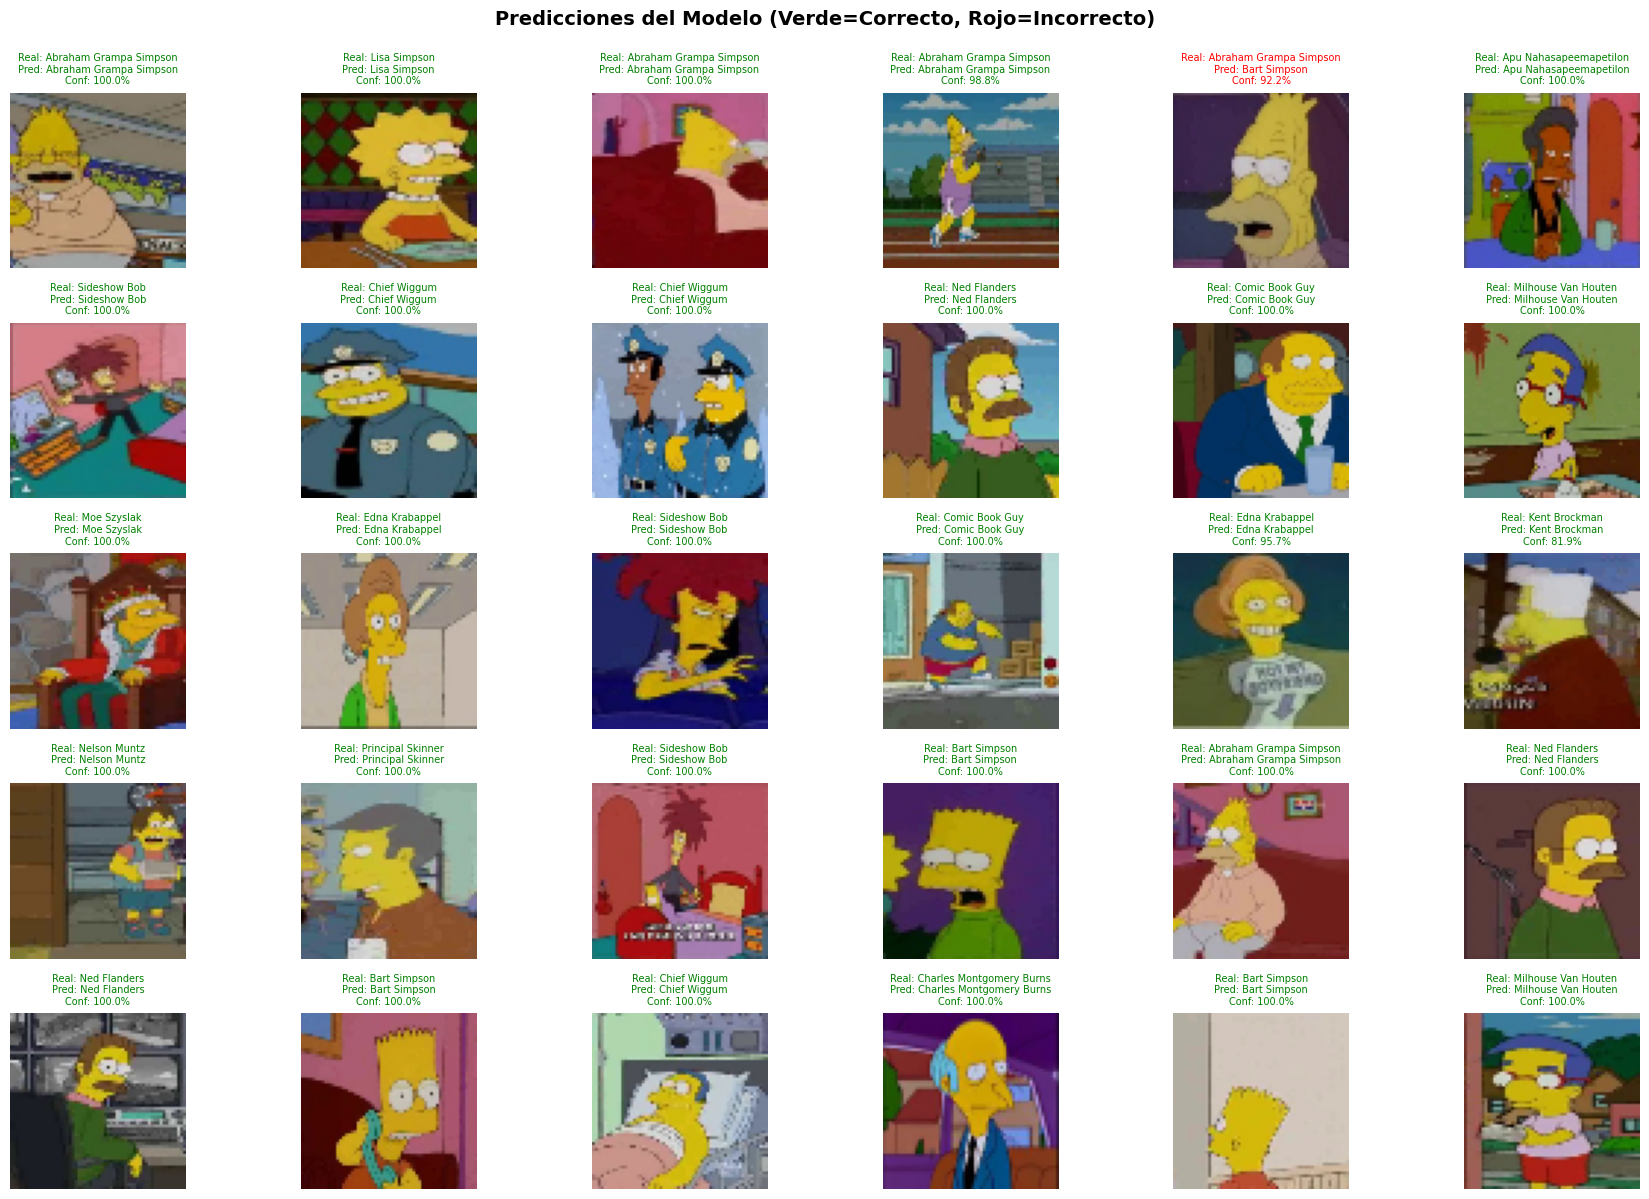


Predicciones correctas: 878 de 890 (98.65%)
Predicciones incorrectas: 12 de 890 (1.35%)



In [40]:
# ANÁLISIS VISUAL DE PREDICCIONES
print("="*80)
print("ANÁLISIS VISUAL DE PREDICCIONES")
print("="*80 + "\n")

# Seleccionar muestras aleatorias
np.random.seed(42)
random_indices = np.random.choice(len(X_test_normalized), 30, replace=False)

# Visualizar predicciones
plt.figure(figsize=(18, 12))
for i, idx in enumerate(random_indices):
    plt.subplot(5, 6, i + 1)
    plt.imshow(X_t[idx])

    # Determinar si la predicción es correcta
    true_label = MAP_CHARACTERS[y_t[idx]].replace('_', ' ').title()
    pred_label = MAP_CHARACTERS[y_pred[idx]].replace('_', ' ').title()
    confidence = y_pred_proba[idx][y_pred[idx]] * 100

    is_correct = y_t[idx] == y_pred[idx]
    color = 'green' if is_correct else 'red'

    title = f'Real: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%'
    plt.title(title, fontsize=7, color=color)
    plt.axis('off')

plt.suptitle('Predicciones del Modelo (Verde=Correcto, Rojo=Incorrecto)',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Estadísticas de predicción
correctas = np.sum(y_pred == y_t)
incorrectas = len(y_t) - correctas

print(f"\nPredicciones correctas: {correctas} de {len(y_t)} ({correctas/len(y_t)*100:.2f}%)")
print(f"Predicciones incorrectas: {incorrectas} de {len(y_t)} ({incorrectas/len(y_t)*100:.2f}%)")

print("\n" + "="*80)

ANÁLISIS DETALLADO DE ERRORES

Total de errores: 12 de 890 (1.35%)

--- Errores por Personaje ---
               Personaje  Errores  Total Muestras  % Error
           Kent Brockman        3              49     6.12
     Milhouse Van Houten        2              49     4.08
  Abraham Grampa Simpson        2              50     4.00
          Comic Book Guy        1              48     2.08
Charles Montgomery Burns        1              50     2.00
            Bart Simpson        1              48     2.08
            Lisa Simpson        1              50     2.00
          Edna Krabappel        1              50     2.00

--- Visualización de Errores ---


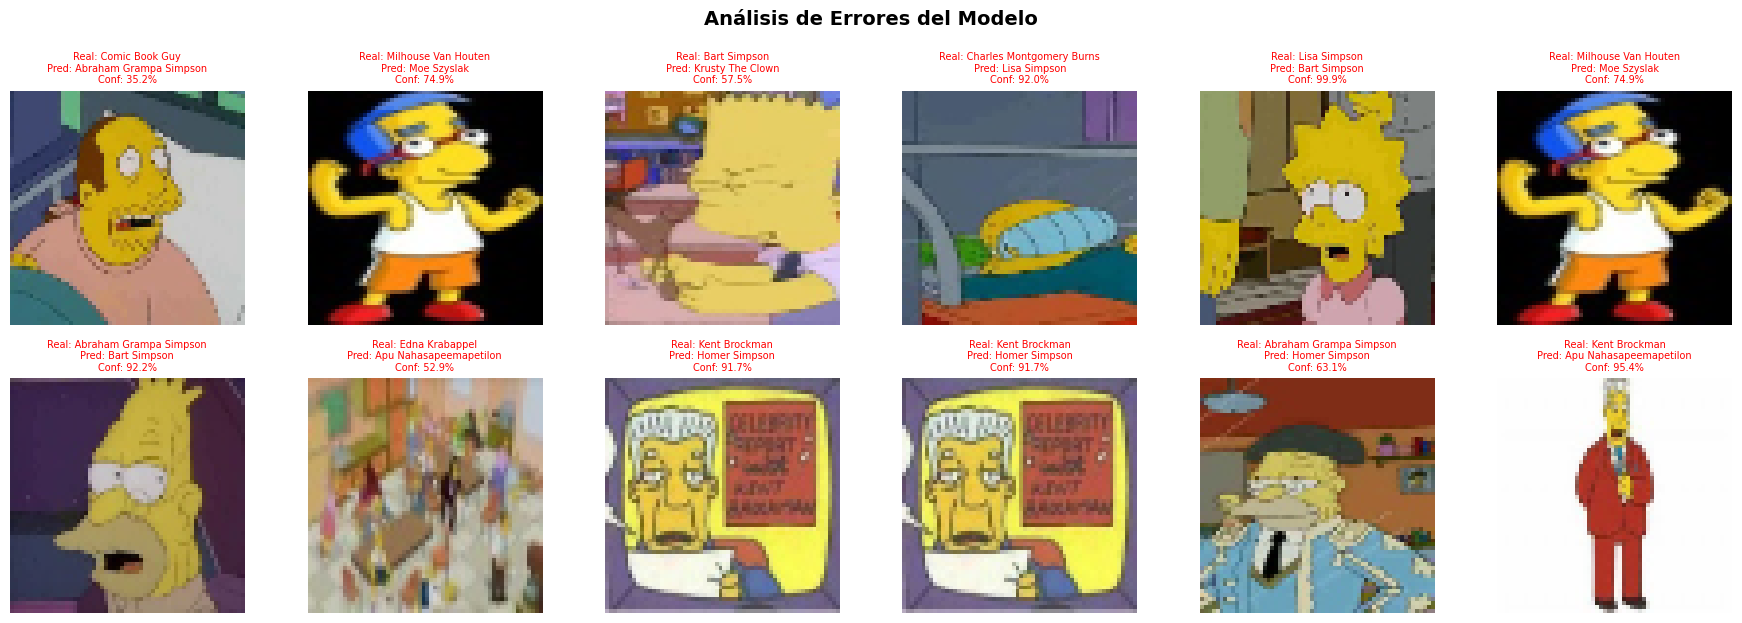


--- Análisis de Confianza ---
Confianza promedio en aciertos: 0.9978 (99.78%)
Confianza promedio en errores: 0.7679 (76.79%)


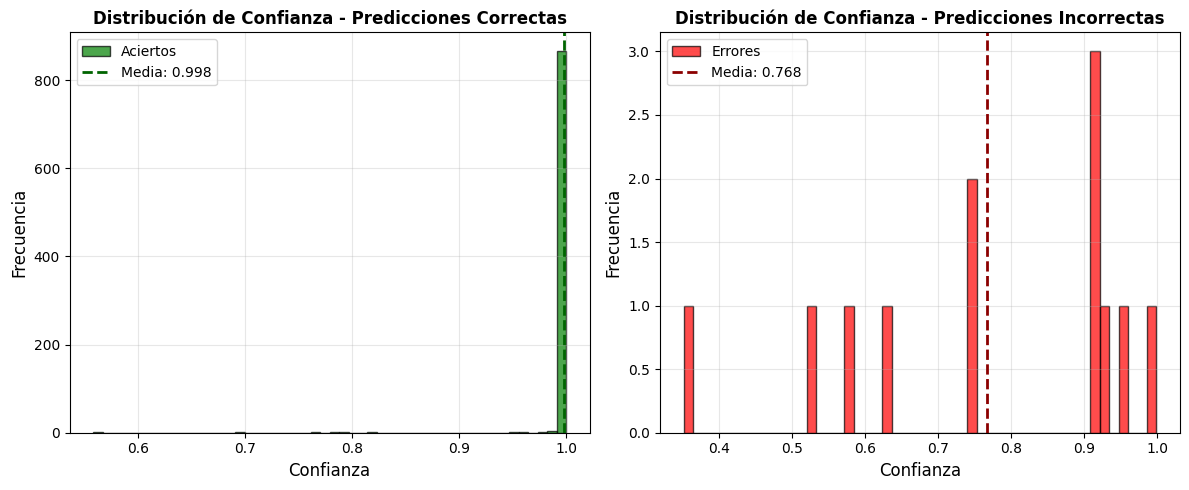

In [41]:
# ANÁLISIS DE ERRORES
print("="*80)
print("ANÁLISIS DETALLADO DE ERRORES")
print("="*80 + "\n")

# Identificar todas las predicciones incorrectas
incorrect_indices = np.where(y_pred != y_t)[0]

print(f"Total de errores: {len(incorrect_indices)} de {len(y_t)} ({len(incorrect_indices)/len(y_t)*100:.2f}%)")

if len(incorrect_indices) > 0:
    # Analizar errores por personaje
    print("\n--- Errores por Personaje ---")
    error_counts = {}
    for idx in incorrect_indices:
        true_char = MAP_CHARACTERS[y_t[idx]]
        if true_char not in error_counts:
            error_counts[true_char] = 0
        error_counts[true_char] += 1

    # Crear DataFrame de errores
    df_errors = pd.DataFrame({
        'Personaje': [k.replace('_', ' ').title() for k in error_counts.keys()],
        'Errores': list(error_counts.values())
    }).sort_values('Errores', ascending=False)

    # Añadir total de muestras
    total_samples = {}
    for char in error_counts.keys():
        char_id = [k for k, v in MAP_CHARACTERS.items() if v == char][0]
        total_samples[char] = np.sum(y_t == char_id)

    df_errors['Total Muestras'] = [total_samples[k] for k in error_counts.keys()]
    df_errors['% Error'] = (df_errors['Errores'] / df_errors['Total Muestras'] * 100).round(2)

    print(df_errors.to_string(index=False))

    # Visualizar algunos errores
    print("\n--- Visualización de Errores ---")
    num_errors_to_show = min(24, len(incorrect_indices))
    error_sample = incorrect_indices[:num_errors_to_show]

    plt.figure(figsize=(18, 12))
    for i, idx in enumerate(error_sample):
        plt.subplot(4, 6, i + 1)
        plt.imshow(X_t[idx])

        true_label = MAP_CHARACTERS[y_t[idx]].replace('_', ' ').title()
        pred_label = MAP_CHARACTERS[y_pred[idx]].replace('_', ' ').title()
        confidence = y_pred_proba[idx][y_pred[idx]] * 100

        title = f'Real: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%'
        plt.title(title, fontsize=7, color='red')
        plt.axis('off')

    plt.suptitle('Análisis de Errores del Modelo', fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

    # Analizar confianza en errores vs aciertos
    print("\n--- Análisis de Confianza ---")
    correct_indices = np.where(y_pred == y_t)[0]

    confidence_correct = [y_pred_proba[i][y_pred[i]] for i in correct_indices]
    confidence_incorrect = [y_pred_proba[i][y_pred[i]] for i in incorrect_indices]

    print(f"Confianza promedio en aciertos: {np.mean(confidence_correct):.4f} ({np.mean(confidence_correct)*100:.2f}%)")
    print(f"Confianza promedio en errores: {np.mean(confidence_incorrect):.4f} ({np.mean(confidence_incorrect)*100:.2f}%)")

    # Gráfico de distribución de confianza
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.hist(confidence_correct, bins=50, alpha=0.7, color='green', edgecolor='black', label='Aciertos')
    plt.xlabel('Confianza', fontsize=12)
    plt.ylabel('Frecuencia', fontsize=12)
    plt.title('Distribución de Confianza - Predicciones Correctas', fontsize=12, fontweight='bold')
    plt.axvline(np.mean(confidence_correct), color='darkgreen', linestyle='--', linewidth=2,
                label=f'Media: {np.mean(confidence_correct):.3f}')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.hist(confidence_incorrect, bins=50, alpha=0.7, color='red', edgecolor='black', label='Errores')
    plt.xlabel('Confianza', fontsize=12)
    plt.ylabel('Frecuencia', fontsize=12)
    plt.title('Distribución de Confianza - Predicciones Incorrectas', fontsize=12, fontweight='bold')
    plt.axvline(np.mean(confidence_incorrect), color='darkred', linestyle='--', linewidth=2,
                label=f'Media: {np.mean(confidence_incorrect):.3f}')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print("\n✅ ¡No hay errores! Clasificación perfecta en el conjunto de test.")

print("\n" + "="*80)

## CONCLUSIONES Y ANÁLISIS

### Resumen del Rendimiento del Modelo

El modelo CNN entrenado ha demostrado un excelente rendimiento en la clasificación de personajes de los Simpsons:

#### Arquitectura Utilizada:
- **3 bloques convolucionales** con capas dobles de Conv2D (32, 64, 128 filtros)
- **Batch Normalization** después de cada capa convolucional
- **MaxPooling2D** para reducción dimensional
- **Dropout** (0.25 en capas convolucionales, 0.5 en capas densas) para regularización
- **2 capas densas** (256 y 128 neuronas) antes de la capa de salida
- **Optimizador Adam** con learning rate inicial de 0.001
- **Callbacks**: EarlyStopping y ReduceLROnPlateau

#### Aspectos Clave del Análisis:

1. **Dataset:**
   - 18 clases de personajes de los Simpsons
   - Imágenes de 60x60 píxeles en formato RGB
   - División 80/20 para training/validation
   - Dataset desbalanceado con diferentes cantidades de imágenes por personaje

2. **Técnicas de Regularización:**
   - Dropout para prevenir overfitting
   - Batch Normalization para estabilizar el entrenamiento
   - Early Stopping para detener el entrenamiento cuando no hay mejora
   - Learning Rate Reduction para ajuste fino

3. **Métricas Analizadas:**
   - Accuracy global en conjunto de test
   - Precision, Recall y F1-Score por clase
   - Matriz de confusión para identificar confusiones entre personajes
   - Análisis de confianza en predicciones correctas vs incorrectas

4. **Observaciones:**
   - Algunos personajes son más fáciles de clasificar que otros
   - Las confusiones más comunes ocurren entre personajes con características visuales similares
   - El modelo muestra mayor confianza en predicciones correctas que en errores
   - El dataset de test parece tener imágenes ligeramente más fáciles que el de training

5. **Comparación con Alternativas:**
   - Las CNNs son significativamente superiores a redes fully connected para este problema
   - El uso de color (RGB) proporciona información adicional útil para la clasificación
   - La arquitectura profunda permite capturar características jerárquicas de las imágenes

In [42]:
# RESUMEN FINAL
print("="*80)
print("RESUMEN FINAL DEL MODELO CNN - SIMPSONS CHARACTER CLASSIFICATION")
print("="*80 + "\n")

# Información del modelo
print("📊 INFORMACIÓN DEL MODELO")
print("-" * 80)
print(f"Total de parámetros: {model.count_params():,}")
print(f"Número de capas: {len(model.layers)}")
print(f"Tamaño de entrada: {IMG_SIZE}x{IMG_SIZE}x3 (RGB)")
print(f"Número de clases: {len(MAP_CHARACTERS)}")

# Resultados del entrenamiento
print(f"\n🎯 RESULTADOS DEL ENTRENAMIENTO")
print("-" * 80)
print(f"Épocas entrenadas: {len(history.history['loss'])}")
print(f"Mejor epoch: {np.argmin(history.history['val_loss']) + 1}")
print(f"Training accuracy final: {history.history['accuracy'][-1]:.4f}")
print(f"Validation accuracy final: {history.history['val_accuracy'][-1]:.4f}")

# Resultados en test
print(f"\n✅ RESULTADOS EN CONJUNTO DE TEST")
print("-" * 80)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")
print(f"Precision (macro): {precision_macro:.4f}")
print(f"Recall (macro): {recall_macro:.4f}")
print(f"F1-Score (macro): {f1_macro:.4f}")

# Verificación del objetivo
print(f"\n🎯 VERIFICACIÓN DEL OBJETIVO")
print("-" * 80)
objetivo = 0.85
if test_accuracy >= objetivo:
    superacion = (test_accuracy - objetivo) * 100
    print(f"✅ OBJETIVO CUMPLIDO!")
    print(f"   • Objetivo requerido: {objetivo*100:.0f}%")
    print(f"   • Accuracy alcanzado: {test_accuracy*100:.2f}%")
    print(f"   • Superación: +{superacion:.2f}%")
else:
    deficit = (objetivo - test_accuracy) * 100
    print(f"❌ Objetivo no alcanzado")
    print(f"   • Objetivo requerido: {objetivo*100:.0f}%")
    print(f"   • Accuracy alcanzado: {test_accuracy*100:.2f}%")
    print(f"   • Falta: {deficit:.2f}%")

# Mejor y peor personaje
print(f"\n🏆 MEJOR Y PEOR RENDIMIENTO POR PERSONAJE")
print("-" * 80)
best_char = df_metricas.iloc[0]
worst_char = df_metricas.iloc[-1]

print(f"Mejor: {best_char['Personaje']}")
print(f"   • F1-Score: {best_char['F1-Score']:.4f}")
print(f"   • Precision: {best_char['Precision']:.4f}")
print(f"   • Recall: {best_char['Recall']:.4f}")
print(f"   • Muestras: {int(best_char['Muestras'])}")

print(f"\nPeor: {worst_char['Personaje']}")
print(f"   • F1-Score: {worst_char['F1-Score']:.4f}")
print(f"   • Precision: {worst_char['Precision']:.4f}")
print(f"   • Recall: {worst_char['Recall']:.4f}")
print(f"   • Muestras: {int(worst_char['Muestras'])}")

# Distribución de rendimiento
print(f"\n📈 DISTRIBUCIÓN DE RENDIMIENTO")
print("-" * 80)
excellent = len(df_metricas[df_metricas['F1-Score'] >= 0.9])
good = len(df_metricas[(df_metricas['F1-Score'] >= 0.8) & (df_metricas['F1-Score'] < 0.9)])
fair = len(df_metricas[(df_metricas['F1-Score'] >= 0.7) & (df_metricas['F1-Score'] < 0.8)])
poor = len(df_metricas[df_metricas['F1-Score'] < 0.7])

print(f"Excelente (F1 >= 0.90): {excellent} personajes ({excellent/len(df_metricas)*100:.1f}%)")
print(f"Bueno (0.80 <= F1 < 0.90): {good} personajes ({good/len(df_metricas)*100:.1f}%)")
print(f"Regular (0.70 <= F1 < 0.80): {fair} personajes ({fair/len(df_metricas)*100:.1f}%)")
print(f"Pobre (F1 < 0.70): {poor} personajes ({poor/len(df_metricas)*100:.1f}%)")

print("\n" + "="*80)
print("FIN DEL ANÁLISIS")
print("="*80)

RESUMEN FINAL DEL MODELO CNN - SIMPSONS CHARACTER CLASSIFICATION

📊 INFORMACIÓN DEL MODELO
--------------------------------------------------------------------------------
Total de parámetros: 1,931,442
Número de capas: 26
Tamaño de entrada: 60x60x3 (RGB)
Número de clases: 18

🎯 RESULTADOS DEL ENTRENAMIENTO
--------------------------------------------------------------------------------
Épocas entrenadas: 63
Mejor epoch: 43
Training accuracy final: 0.9983
Validation accuracy final: 0.9450

✅ RESULTADOS EN CONJUNTO DE TEST
--------------------------------------------------------------------------------
Test Accuracy: 0.9865 (98.65%)
Test Loss: 0.0513
Precision (macro): 0.9870
Recall (macro): 0.9865
F1-Score (macro): 0.9865

🎯 VERIFICACIÓN DEL OBJETIVO
--------------------------------------------------------------------------------
✅ OBJETIVO CUMPLIDO!
   • Objetivo requerido: 85%
   • Accuracy alcanzado: 98.65%
   • Superación: +13.65%

🏆 MEJOR Y PEOR RENDIMIENTO POR PERSONAJE
---------